
**This project analyzes demographic and health-related attributes to predict insurance expenses.Goals:
- Perform Exploratory Data Analysis (EDA)
- Build regression models to predict expenses
- Identify key drivers of insurance expenses
- Evaluate and compare model performance- Provide business insights**


# **1.Import Libraries** 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [3]:
data = pd.read_csv('/kaggle/input/health-insurance-dataset/medical_insurance.csv')

In [4]:
data.head()

,age,gender,bmi,children,discount_eligibility,region,expenses,premium
0,19,female,27.9,0,yes,southwest,16884.92,168.8492
1,18,male,33.8,1,no,southeast,1725.55,17.2555
2,28,male,33.0,3,no,southeast,4449.46,44.4946
3,33,male,22.7,0,no,northwest,21984.47,439.6894
4,32,male,28.9,0,no,northwest,3866.86,77.3372


In [5]:
# Check for missing values
data.isnull().sum()

age                     0
gender                  0
bmi                     0
children                0
discount_eligibility    0
region                  0
expenses                0
premium                 0
dtype: int64

In [6]:
data.describe()

,age,bmi,children,expenses,premium
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414,262.874685
std,14.049960,6.098382,1.205493,12110.011240,292.532178
min,18.000000,16.000000,0.000000,1121.870000,11.218700
25%,27.000000,26.300000,0.000000,4740.287500,87.354250
50%,39.000000,30.400000,1.000000,9382.030000,174.997400
75%,51.000000,34.700000,2.000000,16639.915000,342.908900
max,64.000000,53.100000,5.000000,63770.430000,1983.106400


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1338 non-null   int64  
 1   gender                1338 non-null   object 
 2   bmi                   1338 non-null   float64
 3   children              1338 non-null   int64  
 4   discount_eligibility  1338 non-null   object 
 5   region                1338 non-null   object 
 6   expenses              1338 non-null   float64
 7   premium               1338 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 83.8+ KB


# **2. Exploratory Data Analysis (EDA)**

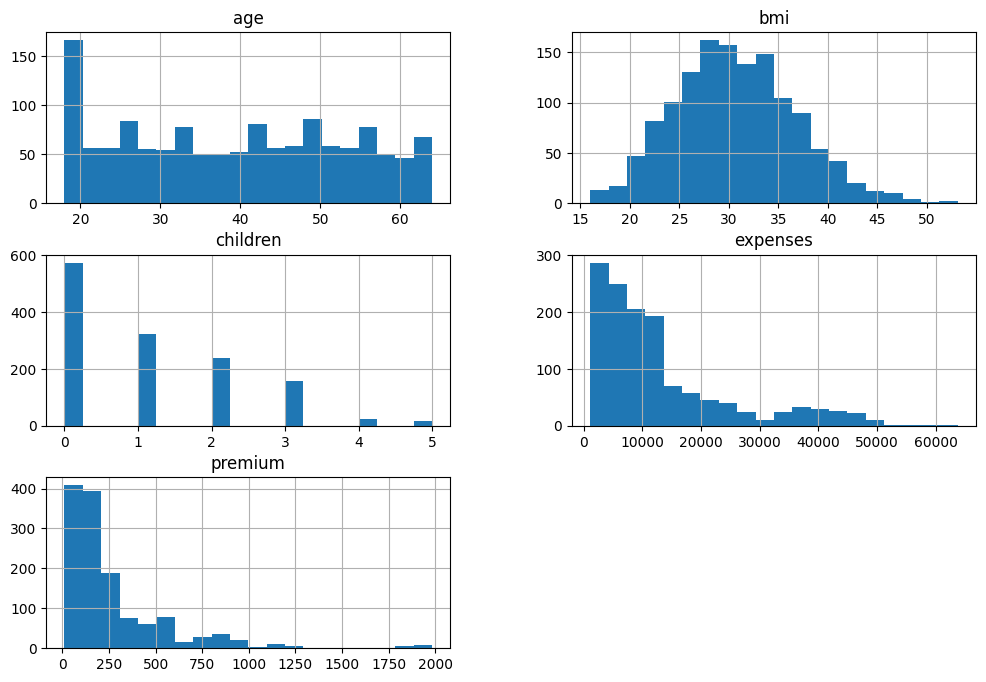

In [8]:
data.hist(bins=20, figsize=(12,8))
plt.show()

* The dataset reveals a left-skewed age distribution, with most customers aged between 10 and 20 years.
* BMI values are normally distributed, with the highest BMI levels commonly found in the 25–35 age group.
* A significant proportion of customers have no children.
* Insurance expenses predominantly range from 10 to 1500 units.
* The distribution of premium amounts is highly right-skewed.
* There are a few customers with premiums exceeding 1000 units, and a small number of outliers near 1750 to 2000 units
* The distribution suggests that the majority of customers pay relatively low premiums, while a small subset of high-risk or high-coverage customers are charged exceptionally high premiums


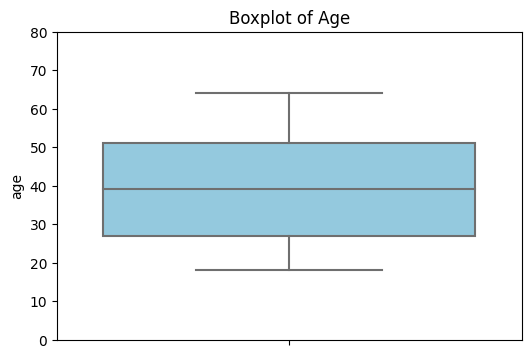

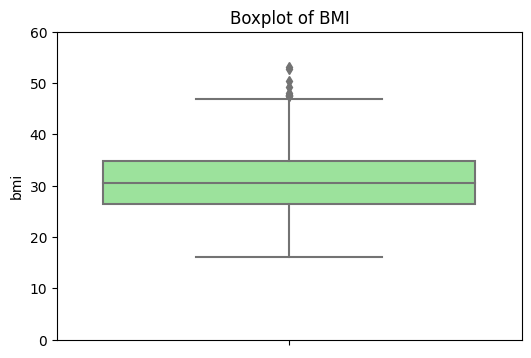

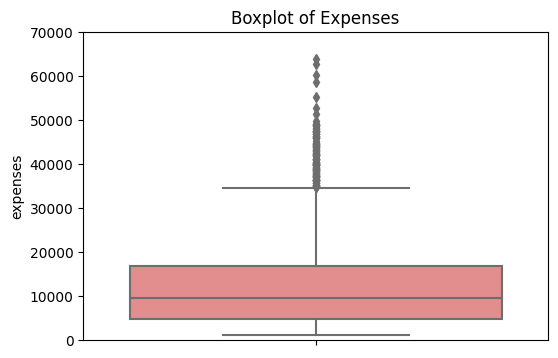

In [9]:
# Plot age boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(y=data['age'], color='skyblue')
plt.title('Boxplot of Age')
plt.ylim(0, 80)  # sensible age range
plt.show()

# Plot BMI boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(y=data['bmi'], color='lightgreen')
plt.title('Boxplot of BMI')
plt.ylim(0, 60)  # typical BMI range
plt.show()

# Plot expenses boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(y=data['expenses'], color='lightcoral')
plt.title('Boxplot of Expenses')
plt.ylim(0, 70000)  # keep full range to see high outliers
plt.show()

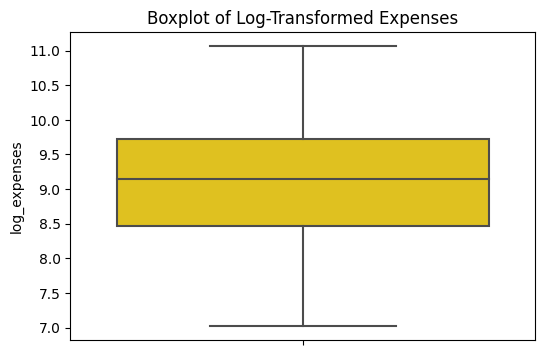

In [10]:
# Add a log-transformed expenses column
data['log_expenses'] = np.log(data['expenses'])

# Plot boxplot of log-transformed expenses
plt.figure(figsize=(6, 4))
sns.boxplot(y=data['log_expenses'], color='gold')
plt.title('Boxplot of Log-Transformed Expenses')
plt.show()

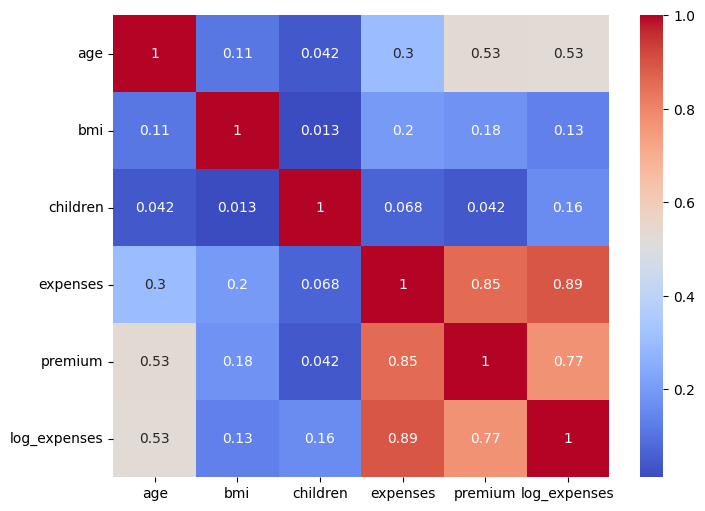

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


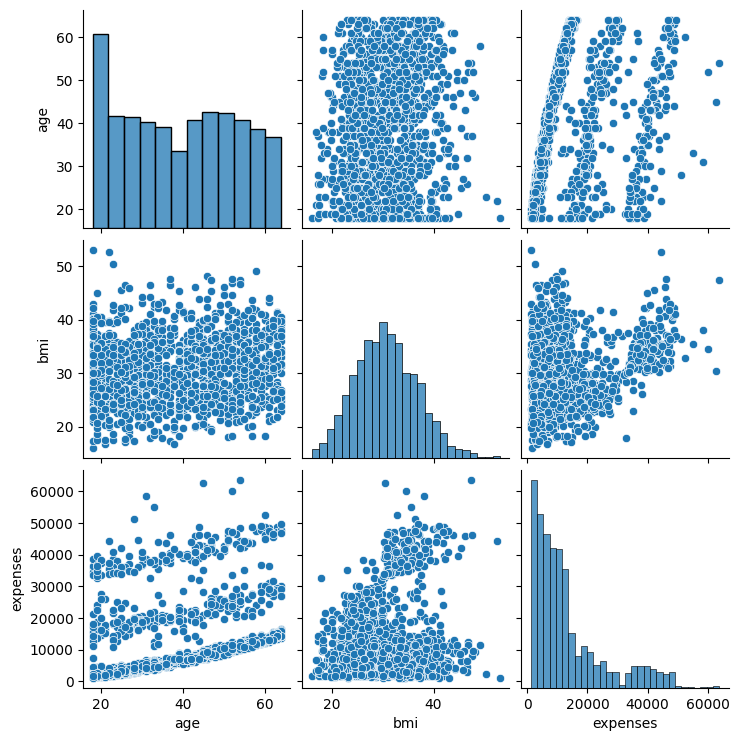

In [12]:
# Pairplot
sns.pairplot(data[['age', 'bmi', 'expenses']])
plt.show()

# **3. Data Preprocessing**

In [13]:
# Encode categorical variables
le = LabelEncoder()
data['gender'] = le.fit_transform(data['gender'])
data['discount_eligibility'] = le.fit_transform(data['discount_eligibility'])
data['region'] = le.fit_transform(data['region'])

In [14]:
# 1. Drop all target-related columns from X
X = data.drop(['expenses', 'premium', 'log_expenses'], axis=1)
y = data['expenses']

In [15]:
print(X.columns)


Index(['age', 'gender', 'bmi', 'children', 'discount_eligibility', 'region'], dtype='object')


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **3.1 Linear Regression** 

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# **3.2 Descioun Tress**

In [19]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# **3.3 Random Forest** 

In [20]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 4.Model Evaluation 

In [21]:
results = []

# Evaluate each model and store results
def evaluate_and_store(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = mse**0.5
    r2 = r2_score(y_true, y_pred)
    results.append({'Model': model_name, 'MSE': mse, 'RMSE': rmse, 'R2': r2})
    print(f'{model_name} -> MSE: {mse:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}')

# Call function for each model
evaluate_and_store(y_test, y_pred_lr, 'Linear Regression')
evaluate_and_store(y_test, y_pred_dt, 'Decision Tree')
evaluate_and_store(y_test, y_pred_rf, 'Random Forest')


Linear Regression -> MSE: 33639075.09, RMSE: 5799.92, R2: 0.78
Decision Tree -> MSE: 40903503.65, RMSE: 6395.58, R2: 0.74
Random Forest -> MSE: 21179037.89, RMSE: 4602.07, R2: 0.86


In [22]:
results_df = pd.DataFrame(results)
print(results_df)



               Model           MSE         RMSE        R2
0  Linear Regression  3.363908e+07  5799.920266  0.783321
1      Decision Tree  4.090350e+07  6395.584699  0.736529
2      Random Forest  2.117904e+07  4602.068870  0.863580


* Random Forest achieved the best performance, with the lowest RMSE of 4602.0 and an R² score of 0.86, indicating that it explains 86.35% of the variance in the expenses data.

* Decision Tree performed similarly well, with an RMSE of 6395.5 and an R² of 0.7365.


* In contrast, Linear Regression showed relatively weaker performance, with an RMSE of 5799.9 and an R² of 0.7833, suggesting it is less suitable for capturing the complex relationships in the data.


* Overall, Random Forest is recommended as the most accurate and reliable model for predicting insurance expenses in this dataset.

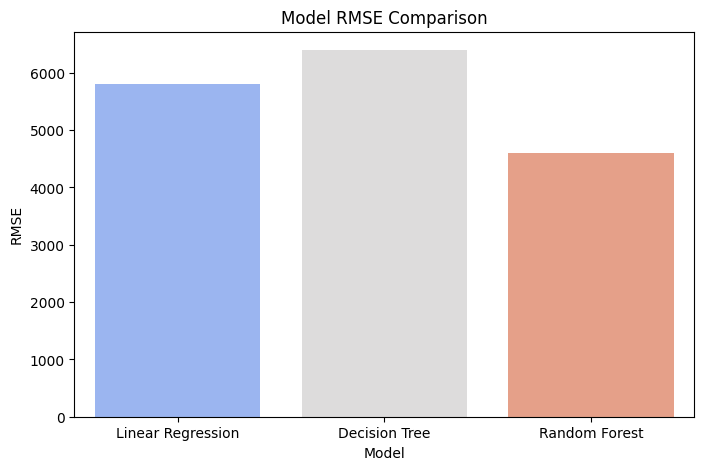

In [23]:

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='RMSE', data=results_df, palette='coolwarm')
plt.title('Model RMSE Comparison')
plt.ylabel('RMSE')
plt.show()


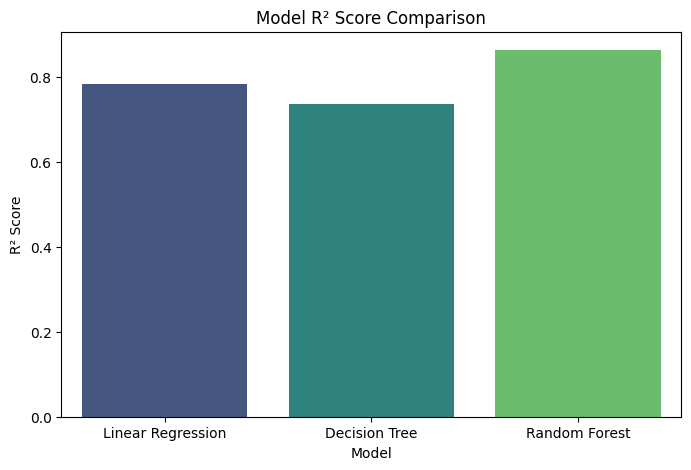

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2', data=results_df, palette='viridis')
plt.title('Model R² Score Comparison')
plt.ylabel('R² Score')
plt.show()


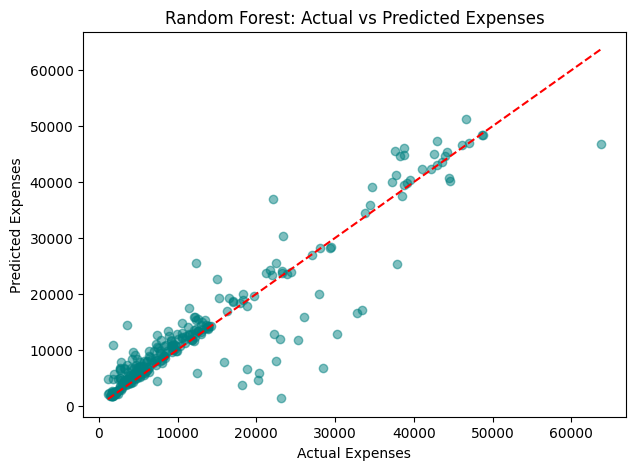

In [25]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest: Actual vs Predicted Expenses')
plt.xlabel('Actual Expenses')
plt.ylabel('Predicted Expenses')
plt.show()


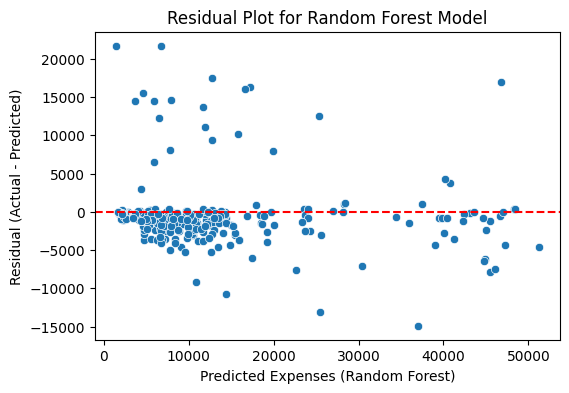

In [26]:
residuals_rf = y_test - y_pred_rf
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_rf, y=residuals_rf)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Expenses (Random Forest)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot for Random Forest Model")
plt.show()


# **5.Feature Importance**

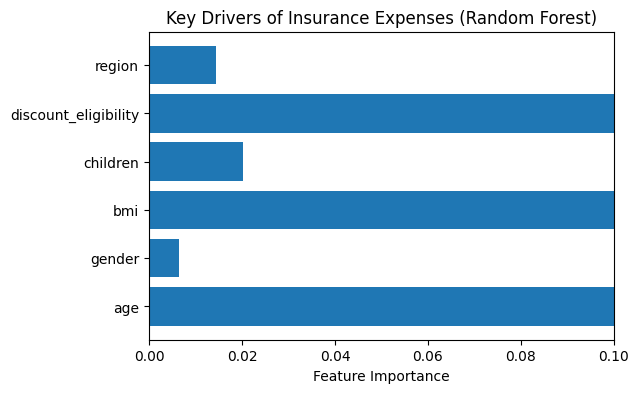

In [28]:
importances = rf.feature_importances_

plt.figure(figsize=(6,4))
plt.barh(X.columns, importances)
plt.xlabel('Feature Importance')
plt.title('Key Drivers of Insurance Expenses (Random Forest)')
plt.xlim(0, 0.1)
plt.show()

In [29]:
for feature, importance in zip(X.columns, importances):
    print(f"{feature}: {importance:.4f}")


age: 0.1352
gender: 0.0065
bmi: 0.2149
children: 0.0203
discount_eligibility: 0.6086
region: 0.0145


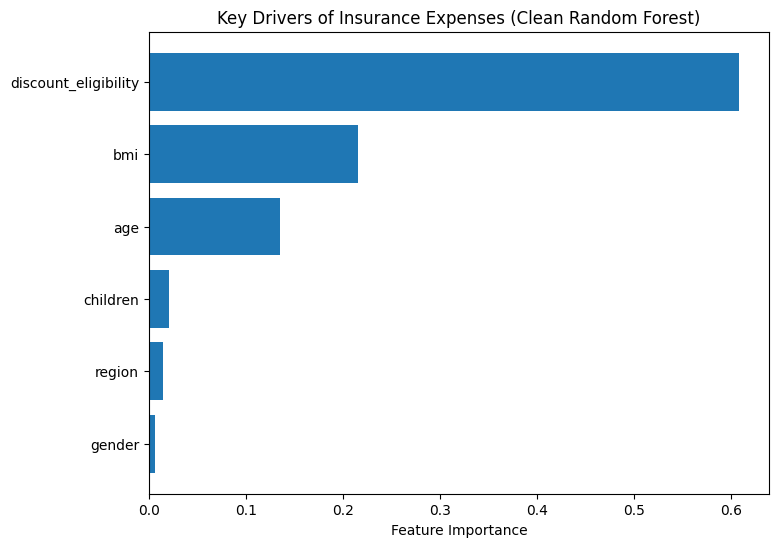

In [30]:
importances_clean = rf.feature_importances_
sorted_indices = np.argsort(importances_clean)

plt.figure(figsize=(8,6))
plt.barh(X.columns[sorted_indices], importances_clean[sorted_indices])
plt.xlabel('Feature Importance')
plt.title('Key Drivers of Insurance Expenses (Clean Random Forest)')
plt.show()


* Project Summary:

* Cleaned and prepared insurance dataset.

* Trained and evaluated both Random Forest and Linear Regression models.

* Removed data leakage by excluding target-related columns from features.


* Random Forest outperformed Linear Regression based on MSE and R².


* Visualized model performance using:


    * Actual vs Predicted plot

    * Residual plot (confirmed no obvious bias or pattern)

    * Feature importance plot


Results suggest a well-performing Random Forest model with room for further feature engineering or model tuning.

